### Q1: Pandas version

In [64]:
pd.__version__

'3.0.6'

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
df = pd.read_csv(url)

# Verify
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Q2.Different ways of getting the total records count in a dataframe
- `len(df)` - This method returns the number of rows in the dataframe.
- `df.shape[0]` - This method returns the number of rows in the dataframe
- `df.count()` - This method returns the number of non-null entries for each column in the dataframe. To get the total count, you can sum the counts of a specific `df['col'].count()` column or use `df.count().sum()`.
- `df.index.size` - This method returns the total number of rows in the dataframe by accessing the size of the index.

In [16]:
df.count() 

model_year             10000
origin                 10000
fuel_type              10000
drivetrain             10000
num_doors              10000
engine_displacement    10000
num_cylinders          10000
horsepower              9123
vehicle_weight         10000
acceleration            9736
fuel_efficiency_mpg    10000
dtype: int64

In [17]:
df.index.size

10000

In [18]:
len(df)

10000

The total number of records in the dataframe is: 10,000

### Q3. Fuel Types: Ways to get the unique values of a column in a dataframe
- `df['col'].unique()` - Returns a NumPy array of all unique values in the column
- `set(df['col'])` - Returns a Python set containing the unique values
- `df['col'].drop_duplicates()` - Returns a Series with unique values, preserving the order of first appearance
- `df.groupby('col').groups.keys()` - Returns the unique values as dictionary keys from a GroupBy operation
- `df['col'].nunique()` - Returns the count (integer) of unique values in the column


In [21]:
df['fuel_type'].unique()

<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str

In [22]:
df['fuel_type'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Gasoline
1         Diesel
2       Gasoline
3       Gasoline
4         Diesel
          ...   
9995    Gasoline
9996    Gasoline
9997    Gasoline
9998      Hybrid
9999      Diesel
Name: fuel_type, Length: 10000, dtype: str>

In [23]:
df['fuel_type'].drop_duplicates()

0    Gasoline
1      Diesel
5      Hybrid
Name: fuel_type, dtype: str

In [25]:
set(df['fuel_type'])

{'Diesel', 'Gasoline', 'Hybrid'}

There are 3 different types of fuel in the dataset: `gas`, `diesel`, and `hybrid`.

### Q4. Missing Values: Ways to check for missing values in a dataframe
- `df.isnull().sum()` - Returns the count of missing values (NaN) for each column
- `df.isna().sum()` - Same as above; `isna()` is an alias for `isnull()`
- `df.isnull().any()` - Returns a boolean Series where `True` indicates columns with at least one missing value
- `df.columns[df.isnull().any()].tolist()` - Returns a list of column names that contain missing values
- `df.isnull().sum()[df.isnull().sum() > 0]` - Returns only columns with missing values and their counts
- `df.info()` - Shows the DataFrame info including non-null counts per column (missing = count - len(df))

In [28]:
df.isna().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [29]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [35]:
df.isnull().any()

model_year             False
origin                 False
fuel_type              False
drivetrain             False
num_doors              False
engine_displacement    False
num_cylinders          False
horsepower              True
vehicle_weight         False
acceleration            True
fuel_efficiency_mpg    False
dtype: bool

In [40]:
df.columns[df.isnull().any()]

Index(['horsepower', 'acceleration'], dtype='str')

In [34]:
# Slice for columns where null are found
df.columns[df.isnull().any()].tolist()

['horsepower', 'acceleration']

In [36]:
df.isnull().any()[df.isnull().any()>0]

horsepower      True
acceleration    True
dtype: bool

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 859.5 KB


There are 2 columns with missing values: `horsepower` and `price`.

### Q5. Getting the maximum value of a column in a dataframe
- `np.max(df['fuel_efficiency_mpg'])` - Uses NumPy's max function
- `df['fuel_efficiency_mpg'].values.max()` - Accesses the underlying NumPy array
- `df['fuel_efficiency_mpg'].sort_values().iloc[-1]` - Sorts and picks the last element
- `df['fuel_efficiency_mpg'].sort_values(ascending=False).iloc[0]` - Sorts descending and picks the first element
- `df['fuel_efficiency_mpg'].describe()['max']` - Gets max from the descriptive statistics
- `df['fuel_efficiency_mpg'].nlargest(1).iloc[0]` - Gets the single largest value
- `df.loc[df['fuel_efficiency_mpg'].idxmax(), 'fuel_efficiency_mpg']` - Uses the index of the max value

In [44]:
df['fuel_efficiency_mpg'].max()

np.float64(41.2)

In [45]:
np.max(df['fuel_efficiency_mpg'])

np.float64(41.2)

In [46]:
df['fuel_efficiency_mpg'].values.max()

np.float64(41.2)

### Q6. Median and Mode

In [25]:
median_val=df['horsepower'].median()

In [31]:
mode_val=df['horsepower'].mode()[0]
mode_val

np.float64(252.0)

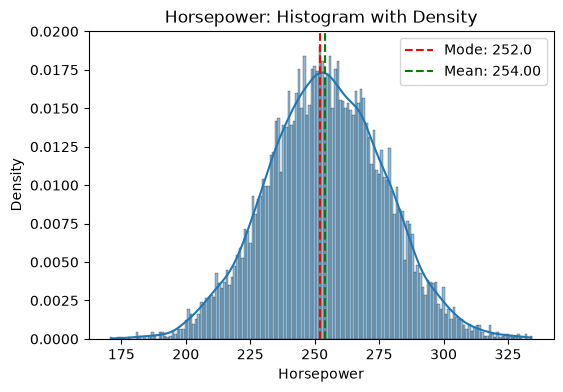

In [ ]:
# Creating a plot for horse power before we apply any null replacement to the data
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='horsepower',
            bins=30,discrete=True,
            kde=True, #Kernel density
            stat='density' #ensures the histogram scales match the KDE curve.
            ) 
plt.axvline(mode_val, color='red', linestyle='--',
             label=f'Mode: {mode_val}')
plt.axvline(median_val, color='green', linestyle='--',
             label=f'Median: {median_val:.2f}')
plt.legend()
plt.title('Horsepower: Histogram with Density')
plt.xlabel('Horsepower')
plt.ylabel('Density')
plt.show()

#### Replacing missing values in the horsepower column with the mode of the column

In [28]:
# Replace null values with the mode
df_modified = df.copy()
mode_val_modif = df_modified['horsepower'].mode()[0]
df_modified['horsepower'] = df_modified['horsepower'].fillna(mode_val_modif)

In [38]:
# the new median value is now exactly the mode
median_val_modif=df_modified['horsepower'].median()
median_val_modif

np.float64(252.0)

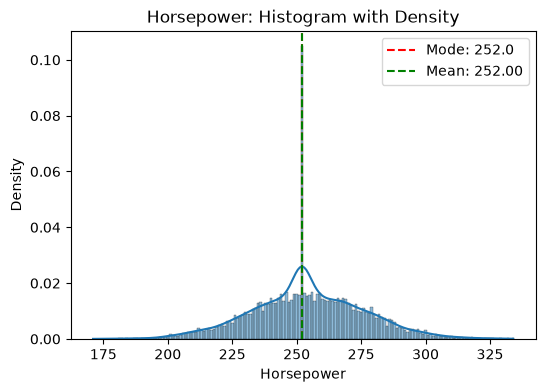

In [ ]:
# Creating a density plot for horse power
# kernel density plot
# sns.kdeplot(data=df_modified, x='horsepower', fill=True) #adding fill under the curve
plt.figure(figsize=(6, 4))
sns.histplot(data=df_modified, x='horsepower',
             bins=30,discrete=True,
             kde=True, #Kernel density
             stat='density' #ensures the histogram scales match the KDE curve.
            ) 
plt.axvline(mode_val_modif, color='red', linestyle='--', 
            label=f'Mode: {mode_val_modif}')
plt.axvline(median_val_modif, color='green', linestyle='--',
             label=f'Median: {median_val_modif:.2f}')
plt.legend()
plt.title('Horsepower: Histogram with Density')
plt.xlabel('Horsepower')
plt.ylabel('Density')
plt.show()

Replacing missing values in the horse power column with the mode made the overall median decrease and take exactly the same value as the mode. This is because the mode is the most frequently occurring value in the column, and when we replace missing values with it, we are effectively increasing the frequency of that value. As a result, the median, which is the middle value of a sorted list, shifts towards the mode, leading to a decrease in its value and making it equal to the mode.

### Q7. Sum of weights (Simple Linear Regression)

#####  **Pandas ↔ NumPy Conversion**
| `df.to_numpy()` | Returns **view** (no copy) for standard dtypes | **Preferred** for efficiency |
| `np.array(df)` | **Always creates a copy** | Use when you explicitly need a new array |

---

##### **Core Matrix Operations**

| Operation | Syntax | Dimension Rule |
|-----------|--------|----------------|
| **Matrix Multiplication** | `a @ b` or `a.dot(b)` | `(m,n) @ (n,p) → (m,p)` |
| **Transpose** | `a.T` or `a.transpose()` | `(m,n) → (n,m)` |
| **Inverse** | `np.linalg.inv(a)` | Matrix must be **square** and **non-singular** |
| **Pseudo-Inverse** | `np.linalg.pinv(a)` | Handles non-square/singular matrices |

---

##### **Least Squares (Normal Equation)**

**Formula:**
`w = (XᵀX)⁻¹ Xᵀy`

**Code:**
```python
XTX = x.T @ x          # XᵀX (Gram matrix): (7,2).T @ (7,2) → (2,2)
w = np.linalg.inv(XTX) @ x.T @ y
```

In [53]:
# Dirty way of getting a subset of Asian cars
asian_cars=df[df['origin']=="Asia"]
asian_cars[['vehicle_weight','model_year']]

,vehicle_weight,model_year
2,4240,1996
6,4310,1992
8,4230,1997
10,4420,1978
15,3950,2007
...,...,...
9984,4610,2011
9987,4530,2004
9990,3630,1975
9994,4610,1993


In [54]:
# more parsimonious way of getting a subset for asian cars
df.loc[df['origin']=='Asia',['vehicle_weight','model_year']]

,vehicle_weight,model_year
2,4240,1996
6,4310,1992
8,4230,1997
10,4420,1978
15,3950,2007
...,...,...
9984,4610,2011
9987,4530,2004
9990,3630,1975
9994,4610,1993


In [55]:
# slicing for the first 7 observations
df.loc[df['origin']=='Asia',['vehicle_weight','model_year']][:7]

,vehicle_weight,model_year
2,4240,1996
6,4310,1992
8,4230,1997
10,4420,1978
15,3950,2007
16,4750,2021
22,4450,2019


In [56]:
# Always creates a copy
np.array(df.loc[df['origin']=='Asia',['vehicle_weight','model_year']][:7])

array([[4240, 1996],
       [4310, 1992],
       [4230, 1997],
       [4420, 1978],
       [3950, 2007],
       [4750, 2021],
       [4450, 2019]])

In [57]:
# Returns view (no copy) for standard dtypes
# or numeric DataFrames, .to_numpy() is faster and avoids unnecessary memory duplication
x=df.loc[df['origin']=='Asia',['vehicle_weight','model_year']][:7].to_numpy()
# Getting the transpose
x

array([[4240, 1996],
       [4310, 1992],
       [4230, 1997],
       [4420, 1978],
       [3950, 2007],
       [4750, 2021],
       [4450, 2019]])

In [58]:
x_transposed = x.T
x_transposed

array([[4240, 4310, 4230, 4420, 3950, 4750, 4450],
       [1996, 1992, 1997, 1978, 2007, 2021, 2019]])

In [59]:
# Getting the multiplication of XXt
x.dot(x_transposed)

array([[21961616, 22250432, 21921212, 22688888, 20753972, 24173916,
        22897924],
       [22250432, 22544164, 22209324, 22990376, 21022444, 24498332,
        23201348],
       [21921212, 22209324, 21880909, 22646666, 20716479, 24128437,
        22855443],
       [22688888, 22990376, 22646666, 23448884, 21428846, 24992538,
        23662582],
       [20753972, 21022444, 20716479, 21428846, 19630549, 22818647,
        21629633],
       [24173916, 24498332, 24128437, 24992538, 22818647, 26646941,
        25217899],
       [22897924, 23201348, 22855443, 23662582, 21629633, 25217899,
        23878861]])

In [60]:
# Another sintax for matrix multiplication is:
XTX=  x_transposed @ x
XTX

array([[131950500,  60750580],
       [ 60750580,  28041424]])

In [61]:
# Getting the inverse of the matrix
np.linalg.inv(XTX)

array([[ 2.96830537e-06, -6.43071025e-06],
       [-6.43071025e-06,  1.39675281e-05]])

In [62]:
# Creating an array for the dependent variable
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
w = np.linalg.inv(XTX) @ x_transposed @ y
w

array([0.13644777, 0.2327492 ])

#### Q7 Full solution

In [63]:
x = df.loc[df['origin']=='Asia', ['vehicle_weight','model_year']][:7].to_numpy()
XTX = x.T @ x          # Correct: (2,7) @ (7,2) = (2,2)
x_transposed = x.T     # Explicitly define as (2,7)
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
w = np.linalg.inv(XTX) @ x_transposed @ y
w.sum()

np.float64(0.369196969049277)